## Imports

In [13]:
from keras import layers, models
from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Load Data


In [14]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


# Prepare Data
from 28 * 28 to 28*28*1 -> 1 = color channel (escala de grises)

In [15]:
train_images = train_images.reshape(60000, 28, 28, 1)
test_images = test_images.reshape(10000, 28, 28,1)
train_images.shape
test_images.shape

(10000, 28, 28, 1)

## Scale Inputs
FROM 0-225 TO 0-1

In [16]:
train_images = train_images / 255.0
test_images = test_images / 255.0


## Prepare Labels

In [17]:
train_labels = to_categorical(train_labels)


# Create Model

In [18]:
model_cnn = models.Sequential([
    # input LAYER
    layers.Input(shape=(28, 28, 1)),

    # 1 hidde LAYER
    layers.Conv2D(32, kernel_size=(3, 3), strides=(1,1), activation='relu',
    padding="same"), # Conv2D por que son fotos->2D                             # 28*28*32

    layers.MaxPooling2D(pool_size=(2, 2),  strides=(2,2)),                      # 14*14*32

    # -------------------------------------------------------------
    # 2 hidde LAYER
    layers.Conv2D(64, kernel_size=(3, 3), strides=(1,1), activation='relu',
    padding="same"), # Conv2D por que son fotos->2D                             # 14*14*64

    layers.MaxPooling2D(pool_size=(2, 2),  strides=(2,2)),                      # 7*7

    # Flatten the output of conv2D
    layers.Flatten(),                                                           # 14*14*32

    # envia en Feature map al la RED-Nnal
    layers.Dense(512, activation='relu'),

    # output LAYER
    layers.Dense(10, activation='softmax')
])




## Summary

In [19]:
model_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,630,090 (6.22 MB)

 Trainable params: 1,630,090 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

# Compile

In [20]:
model_cnn.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

# Trainigs Phase

In [21]:
version = model_cnn.fit(train_images, train_labels, epochs=5, shuffle=True, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9598 - loss: 0.1281 - val_accuracy: 0.9847 - val_loss: 0.0462
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9876 - loss: 0.0400 - val_accuracy: 0.9864 - val_loss: 0.0454
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9920 - loss: 0.0266 - val_accuracy: 0.9883 - val_loss: 0.0439
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9941 - loss: 0.0197 - val_accuracy: 0.9899 - val_loss: 0.0431
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9963 - loss: 0.0128 - val_accuracy: 0.9903 - val_loss: 0.0410


# Plt

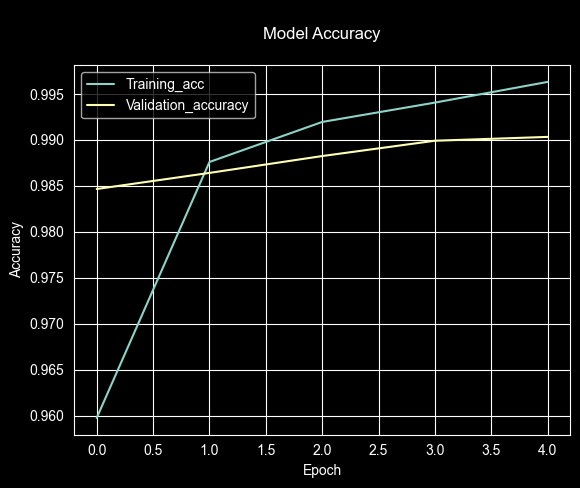

In [22]:
plt.plot(version.history['accuracy'])
plt.plot(version.history['val_accuracy'])
plt.legend(['Training_acc', 'Validation_accuracy'])
plt.title('\nModel Accuracy\n')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

## Prediction

In [23]:
predict = model_cnn.predict(test_images)
rounded_pred = np.argmax(predict, axis=1)
for i in rounded_pred:
    print(i)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
7
2
1
0
4
1
4
9
5
9
0
6
9
0
1
5
9
7
3
4
9
6
6
5
4
0
7
4
0
1
3
1
3
4
7
2
7
1
2
1
1
7
4
2
3
5
1
2
4
4
6
3
5
5
6
0
4
1
9
5
7
8
9
3
7
4
6
4
3
0
7
0
2
9
1
7
3
2
9
7
7
6
2
7
8
4
7
3
6
1
3
6
9
3
1
4
1
7
6
9
6
0
5
4
9
9
2
1
9
4
8
7
3
9
7
4
4
4
9
2
5
4
7
6
7
9
0
5
8
5
6
6
5
7
8
1
0
1
6
4
6
7
3
1
7
1
8
2
0
2
9
9
5
5
1
5
6
0
3
4
4
6
5
4
6
5
4
5
1
4
4
7
2
3
2
7
1
8
1
8
1
8
5
0
8
9
2
5
0
1
1
1
0
9
0
3
1
6
4
2
3
6
1
1
1
3
9
5
2
9
4
5
9
3
9
0
3
6
5
5
7
2
2
7
1
2
8
4
1
7
3
3
8
8
7
9
2
2
4
1
5
9
8
7
2
3
0
6
4
2
4
1
9
5
7
7
2
8
2
6
8
5
7
7
9
1
8
1
8
0
3
0
1
9
9
4
1
8
2
1
2
9
7
5
9
2
6
4
1
5
8
2
9
2
0
4
0
0
2
8
4
7
1
2
4
0
2
7
4
3
3
0
0
3
1
9
6
5
2
5
9
7
9
3
0
4
2
0
7
1
1
2
1
5
3
3
9
7
8
6
3
6
1
3
8
1
0
5
1
3
1
5
5
6
1
8
5
1
7
9
4
6
2
2
5
0
6
5
6
3
7
2
0
8
8
5
4
1
1
4
0
3
3
7
6
1
6
2
1
9
2
8
6
1
9
5
2
5
4
4
2
8
3
8
2
4
5
0
3
1
7
7
5
7
9
7
1
9
2
1
4
2
9
2
0
4
9
1
4
8
1
8
4
5
9
8
8
3
7
6
0
0
3
0
2
0
6
4
9
5
3
3
2
3
9
1
2
6
8
0
5
6
6
6
3
8
8
2
7
5
8
9
6
1
8
4
1
2
5
9

# Confusion Matrix

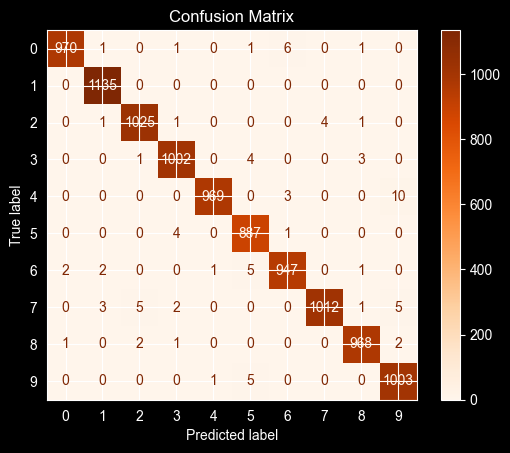

In [25]:
cm = confusion_matrix(test_labels, rounded_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
display.plot(cmap="Oranges", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Se puede seguir desarrollando el analisis del modelo en base al archivo principal, pero el sentido de este archivo es introducir el conv2D